In [ ]:
import pandas as pd
from google.colab import files

uploaded = files.upload()
train = pd.read_csv("dataset_train.csv")
test  = pd.read_csv("dataset_test.csv")
print("Latih:", len(train), "| Uji:", len(test))

Saving dataset_test.csv to dataset_test.csv
Saving dataset_train.csv to dataset_train.csv
Latih: 3476 | Uji: 869


In [ ]:
!pip install Sastrawi -q
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

stemmer   = StemmerFactory().create_stemmer()
stopwords = set(StopWordRemoverFactory().get_stop_words())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 3.1 MB/s eta 0:00:00


In [ ]:
def preprocess_svm(teks):
    if not isinstance(teks, str):
        return ""
    tokens = [t for t in teks.split() if t not in stopwords]  # tokenisasi + buang stopword
    return stemmer.stem(" ".join(tokens))                     # stemming

# CATATAN: proses ini bisa memakan beberapa menit karena stemming
train["teks_svm"] = train["normalized_text"].apply(preprocess_svm)
test["teks_svm"]  = test["normalized_text"].apply(preprocess_svm)

train[["normalized_text", "teks_svm"]].head()

,normalized_text,teks_svm
0,ayo naikkan tagarnya semua sebelum skema peman...,ayo naik tagar semua skema mangkas anggar batal
1,presiden selalu mengeluh negara tidak ada uang...,presiden selalu keluh negara uang lalu cari ja...
2,menkeu sri mulyani tegaskan ptn dilarang menai...,menkeu sri mulyani tegas ptn larang naik ukt m...
3,ini adalah bentuk perlawanan terhadap berbagai...,bentuk lawan bagai bijak perintah nilai makin ...
4,demi gaji amp tunjangan mereka itu juga rakyat...,gaji amp tunjang rakyat genjot bayar pajak rak...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train = tfidf.fit_transform(train["teks_svm"])
X_test  = tfidf.transform(test["teks_svm"])

y_train = train["label"]
y_test  = test["label"]

print("Dimensi TF-IDF latih:", X_train.shape)
print("Dimensi TF-IDF uji  :", X_test.shape)

Dimensi TF-IDF latih: (3476, 5000)
Dimensi TF-IDF uji  : (869, 5000)


In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

svm = SVC(kernel="linear", class_weight="balanced", decision_function_shape="ovo")

param = {"C": [0.1, 1, 10, 100]}
grid = GridSearchCV(svm, param, cv=5, scoring="f1_macro", n_jobs=-1)
grid.fit(X_train, y_train)

print("Nilai C terbaik:", grid.best_params_)
model_svm = grid.best_estimator_

Nilai C terbaik: {'C': 1}


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = model_svm.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%\n")
print(classification_report(y_test, y_pred, digits=4))
print("Confusion Matrix (urutan: negatif, netral, positif):")
print(confusion_matrix(y_test, y_pred, labels=["negatif", "netral", "positif"]))

Accuracy: 84.46 %

              precision    recall  f1-score   support

     negatif     0.9327    0.8970    0.9145       757
      netral     0.2941    0.1852    0.2273        27
     positif     0.4032    0.5882    0.4785        85

    accuracy                         0.8446       869
   macro avg     0.5433    0.5568    0.5401       869
weighted avg     0.8611    0.8446    0.8505       869

Confusion Matrix (urutan: negatif, netral, positif):
[[679  11  67]
 [ 15   5   7]
 [ 34   1  50]]


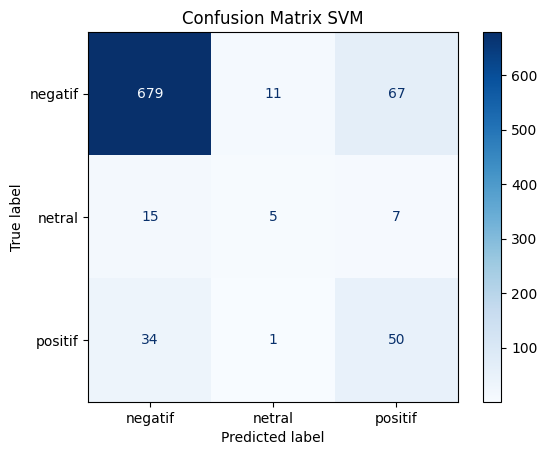

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    labels=["negatif", "netral", "positif"],
    cmap="Blues"
)
plt.title("Confusion Matrix SVM")
plt.show()